# Customer Churn Analysis

## 1. Introduction

Customer churn is an important business problem for subscription-based services because losing existing customers can directly affect revenue and long-term customer value.

This project analyzes customer, subscription, and customer-support data to understand customer churn patterns and identify factors associated with customer cancellations.

The analysis combines data from three database tables: customer information, subscription details, and customer-support interactions. The data is processed and analyzed using Python, Pandas, SQLite, Matplotlib, and Seaborn.

The project focuses on measuring overall churn, identifying high-risk customer segments, evaluating revenue at risk, and examining the relationship between customer-support escalations and churn.

## 2. Business Problem

The primary business problem addressed in this project is customer churn. The objective is to understand why customers leave a subscription-based service and identify customer segments that may require greater attention.

The analysis aims to answer the following business questions:

- How many customers are leaving the service?
- Which subscription plans have higher churn rates?
- Which states or regions show higher customer churn?
- How much monthly revenue is associated with churned customers?
- Is there a relationship between customer-support escalations and churn?
- Which customers fall into low, medium, or high churn-risk categories?

These insights can help a business identify areas that require greater attention and support data-driven customer-retention strategies.

## 3. Project Objectives

The main objectives of this customer churn analysis are:

1. Calculate the overall customer churn and retention rates.
2. Analyze churn across different subscription plans and subscription types.
3. Identify states or regions with higher customer churn.
4. Calculate key business metrics such as Average Revenue Per User (ARPU), average customer tenure, and revenue at risk.
5. Analyze customer-support complaints and escalation patterns.
6. Examine the relationship between customer-support escalations and customer churn.
7. Classify customers into low, medium, and high churn-risk categories using the available churn score.
8. Create visualizations and summary analyses to communicate important churn patterns.
9. Generate business-oriented insights that can support customer-retention strategies.

## 4. Dataset and Data Sources

The customer churn data is stored in a SQLite database named `customer_churn.db`.

The database contains three main tables that provide different aspects of customer information:

### 4.1 Customer Table — `db_customer`

This table contains basic customer information, including:

- Customer ID
- Customer name
- Country
- State
- Gender
- Date of birth
- Interests
- Pincode

### 4.2 Subscription Table — `db_subscription`

This table contains customer subscription and revenue-related information, including:

- Customer ID
- Subscription start date
- Subscription type
- Renewal date
- Plan type
- Contract type
- Cancellation date
- Cancellation reason
- Monthly charges
- Customer Lifetime Value (CLTV)
- Churn score

### 4.3 Support Table — `db_support`

This table contains customer-support interaction information, including:

- Customer ID
- Complaint date
- Escalation status
- CSAT score
- Customer comments

### 4.4 Data Integration

The three datasets are integrated using `customerid` as the common key. This creates a consolidated dataset containing customer, subscription, and customer-support information for further churn analysis.

## 5. Data Loading and Initial Inspection

The customer churn data is stored in a SQLite database named `customer_churn.db`.

### 5.1 Database Connection

The SQLite database is connected using Python's built-in `sqlite3` library. A SQL query is used to inspect the database schema and identify the available tables.

### 5.2 Table Extraction

The available table names are retrieved from SQLite's `sqlite_master` system table.

Each identified table is then loaded into a Pandas DataFrame using `pd.read_sql()`.

This approach brings the customer, subscription, and support datasets into the Python environment for further analysis.

### 5.3 DataFrames Created

The extracted tables are stored as separate Pandas DataFrames so that they can be inspected, cleaned, transformed, and later integrated using the common `customerid` field.

## 6. Data Cleaning & Preprocessing

Data cleaning and preprocessing is an important step in preparing the raw data for reliable analysis. In this project, the customer, subscription, and support datasets were reviewed and cleaned to improve data quality, maintain consistent formats, handle missing values, and remove unnecessary fields.

The following preprocessing tasks were performed:

- Renamed columns to improve clarity and readability.
- Removed irrelevant or completely empty columns.
- Converted date columns into appropriate datetime formats.
- Standardized categorical values for consistency.
- Handled missing values using relevant information available within the dataset.
- Cleaned the support dataset by retaining only the required analytical fields.

These steps ensure that the datasets are consistent and suitable for the subsequent feature engineering, data integration, and exploratory data analysis stages.

### 6.1 Customer Data Cleaning

The customer dataset was cleaned to improve data consistency and ensure that the available fields were suitable for further analysis.

The following cleaning operations were performed:

- Renamed the `name` column to `customer_name` for better clarity and readability.
- Removed the `interests` and `pincode` columns as they were not suitable for the planned analysis.
- Converted the `dob` column from its original format into a proper datetime format.
- Standardized gender values by converting `Men` to `Male` and `Women` to `Female`.
- Identified missing values in the `country` column and filled them using the corresponding state-country relationship available in the dataset.

After these transformations, the customer dataset contained consistent column names, standardized categorical values, an appropriate date format, and completed country information.

### 6.2 Subscription Data Cleaning

The subscription dataset contains important information related to customer subscriptions, plans, contracts, cancellations, and billing.

The following preprocessing operation was performed:

- Converted `subscription_start_date`, `renewal_date`, and `cancellation_date` into appropriate datetime formats.

Converting these columns into datetime format ensures that subscription timelines and cancellation periods can be accurately used for further analysis and feature engineering.

### 6.3 Support Data Cleaning

The support dataset contains information related to customer complaints, escalations, and customer satisfaction scores.

The following preprocessing operations were performed:

- Removed the `col_1` column as it contained no available values.
- Removed the `comment` column to retain the required analytical fields.
- Converted the `complaint_date` column into an appropriate datetime format.

After cleaning, the support dataset retained the relevant fields required for analyzing customer complaints, escalations, and satisfaction scores.

### 6.4 Data Quality Validation

After completing the cleaning operations, the datasets were validated to ensure that the applied transformations were successful and that the data was ready for further analysis.

The validation process included:

- Checking the structure and dimensions of the cleaned datasets.
- Verifying that the required columns were retained.
- Confirming that date columns were converted to the appropriate datetime format.
- Checking data types and non-null values using DataFrame information.
- Ensuring that categorical values were standardized consistently.

The cleaned datasets are now ready for feature engineering, data integration, and further exploratory analysis.

# 7. Feature Engineering and Data Transformation

To prepare the raw dataset for analytical modeling and integrate core business logic, key features were engineered and transformed:

## 7.1 Target Indicator Creation (churn_flag)
A binary indicator was assigned to capture customer churn status based on cancellation records:
$$churn\_flag = \begin{cases} 1 & \text{if } cancellation\_date \text{ is not null} \\ 0 & \text{otherwise} \end{cases}$$

## 7.2 Customer Tenure Calculation (tenure_days)
Active tenure was computed based on the subscription lifespan:
* **Churned Customers:** cancellation_date - subscription_start_date
* **Active Customers:** current_date - subscription_start_date

## 7.3 Risk Segmentation (churn_risk)
Categorical binning was applied to churn_score to group customers into risk profiles:
* **Low Risk:** churn_score < 50
* **Medium Risk:** 50 <= churn_score < 70
* **High Risk:** churn_score >= 70

## 7.4 Support Aggregation (complaint_count)
Customer support interaction records were aggregated to compute the total complaint count per customer.

---

# 8. Exploratory Data Analysis (EDA) and Key Metrics

High-level KPIs were computed to evaluate business performance, customer retention, and underlying churn dynamics:

## 8.1 Core Business KPIs Summary

| Metric | Calculated Value | Business Impact |
| :--- | :--- | :--- |
| **Overall Churn Rate** | **28.57%** | Contraction rate of the active user base |
| **Retention Rate** | **71.43%** | Healthy repeat subscriber baseline |
| **Average Revenue Per User (ARPU)** | **$18.85** | Baseline monthly revenue yield per subscriber |
| **Average Customer Tenure** | **1,518 Days** | Average customer lifecycle (~4.1 years) |
| **Total Revenue at Risk** | **$73.94k** | Monthly revenue lost directly due to churn |
| **Escalation Rate** | **19.05%** | Proportion of unresolved/critical customer complaints |

---

## 8.2 Segment-Wise Granular Breakdown

### 8.2.1 Churn Rate by Subscription Plan
* **Basic Plan:** 60.00% Churn (Highest Attrition Risk)
* **Standard Plan:** 22.22% Churn
* **Premium Plan:** 14.29% Churn (Highest Customer Retention)

Key Insight: Basic plan users exhibit the highest churn rate, whereas Premium subscribers show significantly stronger retention.

### 8.2.2 Acquisition Channel Impact
| Channel Type | Churn Rate | Total Revenue | User Count |
| :--- | :--- | :--- | :--- |
| **Organic** | **0.00%** | $145.91 | 9 |
| **Paid** | **16.67%** | $174.94 | 6 |
| **Referral** | **83.33%** | $74.94 | 6 |

Key Insight: Customers acquired via Referral channels demonstrate a critical attrition rate of 83.33%.

### 8.2.3 Support Escalations vs Churn Correlation
* **Correlation Coefficient:** r = 0.77 (Strong positive linear correlation between escalation tickets and churn incidence)

# 9. Data Visualizations and Behavioral Analysis

Visual exploratory data analysis was performed using Matplotlib and Seaborn to uncover underlying distributions, correlation patterns, and multi-dimensional behavioral risk factors:

## 9.1 Correlation Heatmap Analysis
Using ordinal encoding on categorical features, a Pearson correlation matrix was generated:
* **Escalations vs Churn Flag:** Displays a strong positive correlation ($r = 0.77$), highlighting customer support failures as the primary behavioral driver of account cancellations.
* **Churn Score vs Churn Flag:** Shows high alignment ($r = 0.86$), validating the accuracy and reliability of the internal churn scoring model.
* **Contract Type vs Churn:** Displays a negative correlation ($r = -0.52$), confirming that long-term annual contracts significantly improve customer retention compared to monthly plans.

## 9.2 Monthly Churn Trend Analysis
Time-series tracking of cancellation dates revealed a significant churn spike in **September 2024 (peak of 2 churned customers)** compared to other months. This highlights specific operational disruptions, service outages, or renewal billing cycles that require further targeted auditing.

## 9.3 Plan Tier Distribution and Churn Rate
Comparative bar plots illustrate stark differences in retention across pricing tiers:
* **Basic Plan:** Highest churn rate at **60.00%**.
* **Standard Plan:** Moderate churn rate at **22.22%**.
* **Premium Plan:** Lowest churn rate at **14.29%**.

## 9.4 Multi-Dimensional Risk Profiling (FacetGrid Analysis)
Evaluating customer distributions across `Plan Type`, `Monthly Charges`, and `Gender` broken down by `Churn Risk` levels showed:
* High-risk customers are heavily concentrated in high monthly charge tiers under Basic and Standard plans.
* Premium subscribers maintain a low churn risk even at higher price points, indicating strong perceived product value and satisfaction.

In [3]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
#1. import database / data

In [4]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table'

"""

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [5]:
# print tables names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [ ]:
# 2. data cleaning

In [8]:
# df_db_customer.head()
df_db_customer.tail()


,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [7]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
# a. rename col - name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gernder
# e. fix missing values - country

In [10]:
# rename col - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10 00:00:00,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07 00:00:00,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,NaN,None


In [15]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [21]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [20]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [25]:
# d. data standardization - gernder

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [26]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [28]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [33]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [34]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [35]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [36]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [37]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [39]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [40]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [41]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [42]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [44]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [ ]:
# 3. Feature Engineering and Data Analysis

In [47]:
# create a new col using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [48]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [68]:
# first fix support table duplicates then merge 
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left')
    .merge(df_db_support, on = 'customerid', how= 'left') )

In [53]:
df_db_subscription.shape

(21, 12)

In [59]:
df.shape

(21, 22)

In [55]:
df_db_subscription['customerid'].nunique()

21

In [56]:
df_db_customer['customerid'].nunique()

21

In [57]:
df_db_support['customerid'].nunique()

7

In [58]:
df_db_support['customerid'].size

9

In [64]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [63]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [66]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [67]:
df_db_support['customerid'].size

7

In [71]:
# merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left')
    .merge(df_db_support, on = 'customerid', how= 'left') )

In [72]:
df.shape

(21, 21)

In [73]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# Data Analysis

In [ ]:
# 1. Churn Rate

In [74]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [75]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [76]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [80]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print("Churn by plan = ", churn_by_plan)

Churn by plan =    plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [83]:
# 4 a. Churn by state + sum(revenue) & count of users

# State data fix (Kathmandu -> Bagmati)
df['state'] = df['state'].replace({'Kathmandu': 'Bagmati'})

# State level aggregation with clear column names
churn_by_state = df.groupby('state').agg(
    churn_rate_pct=('churn_flag', 'mean'),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

# Percentage calculation
churn_by_state['churn_rate_pct'] = (churn_by_state['churn_rate_pct'] * 100).round(2)

churn_by_state

,state,churn_rate_pct,total_revenue,user_count
0,Bagmati,0.00,20.98,2
1,Delhi,25.00,52.96,4
2,Karnataka,100.00,20.98,2
3,Maharashtra,0.00,50.97,3
4,Meghalaya,66.67,42.97,3
5,Nagaland,0.00,22.99,1
6,Rajasthan,0.00,36.98,2
7,Telangana,50.00,30.98,2
8,Uttar Pradesh,0.00,115.98,2


In [84]:
# 4 b. Churn by subscription type + sum(revenue) & count of users

df.groupby('subscription_type').agg(
    churn_rate=('churn_flag', 'mean'),
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

,subscription_type,churn_rate,total_revenue,user_count
0,Organic,0.000000,145.91,9
1,Paid,0.166667,174.94,6
2,Refferal,0.833333,74.94,6


In [87]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [103]:
# 6. Avg Customer Tenture
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure, 0))

Avg Tenure (Days) =  1518.0


In [109]:
# 7. Revenue at risk - revenue Lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at risk (Rs 'k') =", revenue_at_risk)

Revenue at risk (Rs 'k') = 73.94


In [114]:
# 8. Esclation Rate

escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  19.05 %


In [117]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per Uaer = ", round(avg_complaints, 2))

Avg Complaints Per Uaer =  0.43


In [123]:
# 10. Correlation Esclation vs Churn

# df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))



Correlation between esclation vs churn is =  0.77


In [125]:
# 11. create a column using existing col - Churn risk
conditions = [
         (df['churn_score'] < 50),
         (df['churn_score'] >= 50) & (df['churn_score'] < 70),
         (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [ ]:
# 4. Visualization using Matplotlib

In [130]:
df_visual = df.copy()

In [132]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

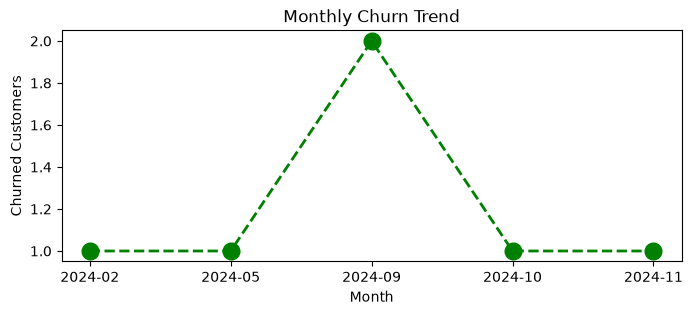

In [138]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

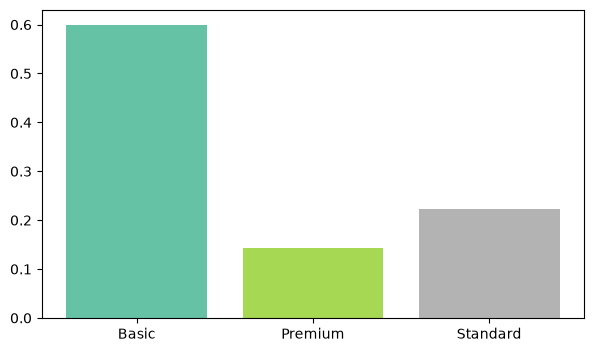

In [144]:
# 4.2 Churn by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

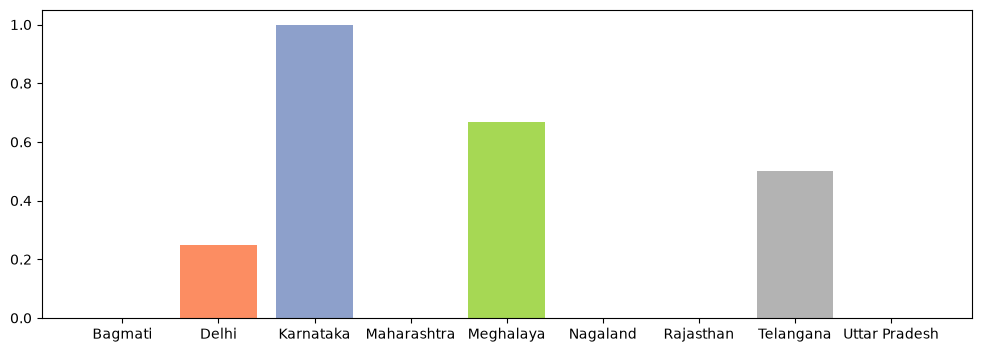

In [146]:
# 4.3 Churn by states
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [ ]:
# Visulaization using Seaborn

In [147]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [148]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [154]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


In [153]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

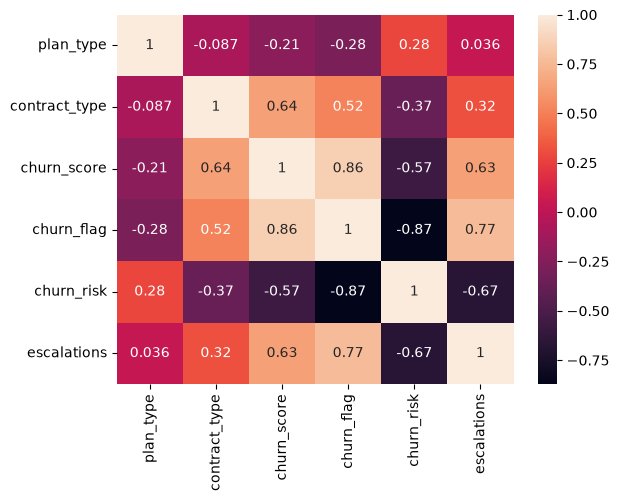

In [155]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [158]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [160]:
# correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {'plan_type' : ['Basic', 'Standard', 'Premium'],
                  'contract_type' : ['Monthly', 'Annual'],
                  'churn_risk' : ['low', 'med', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [162]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [161]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

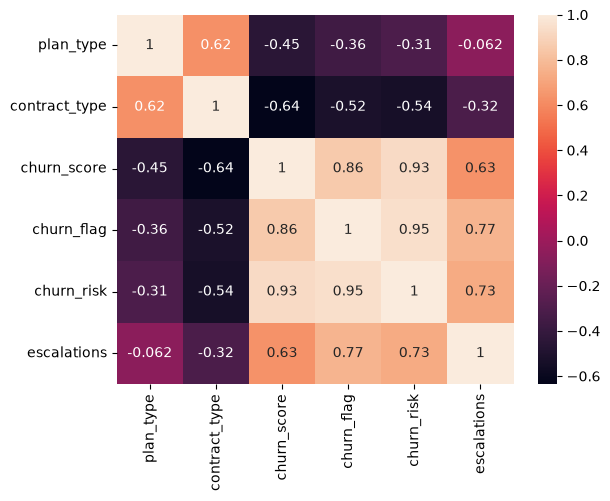

In [163]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

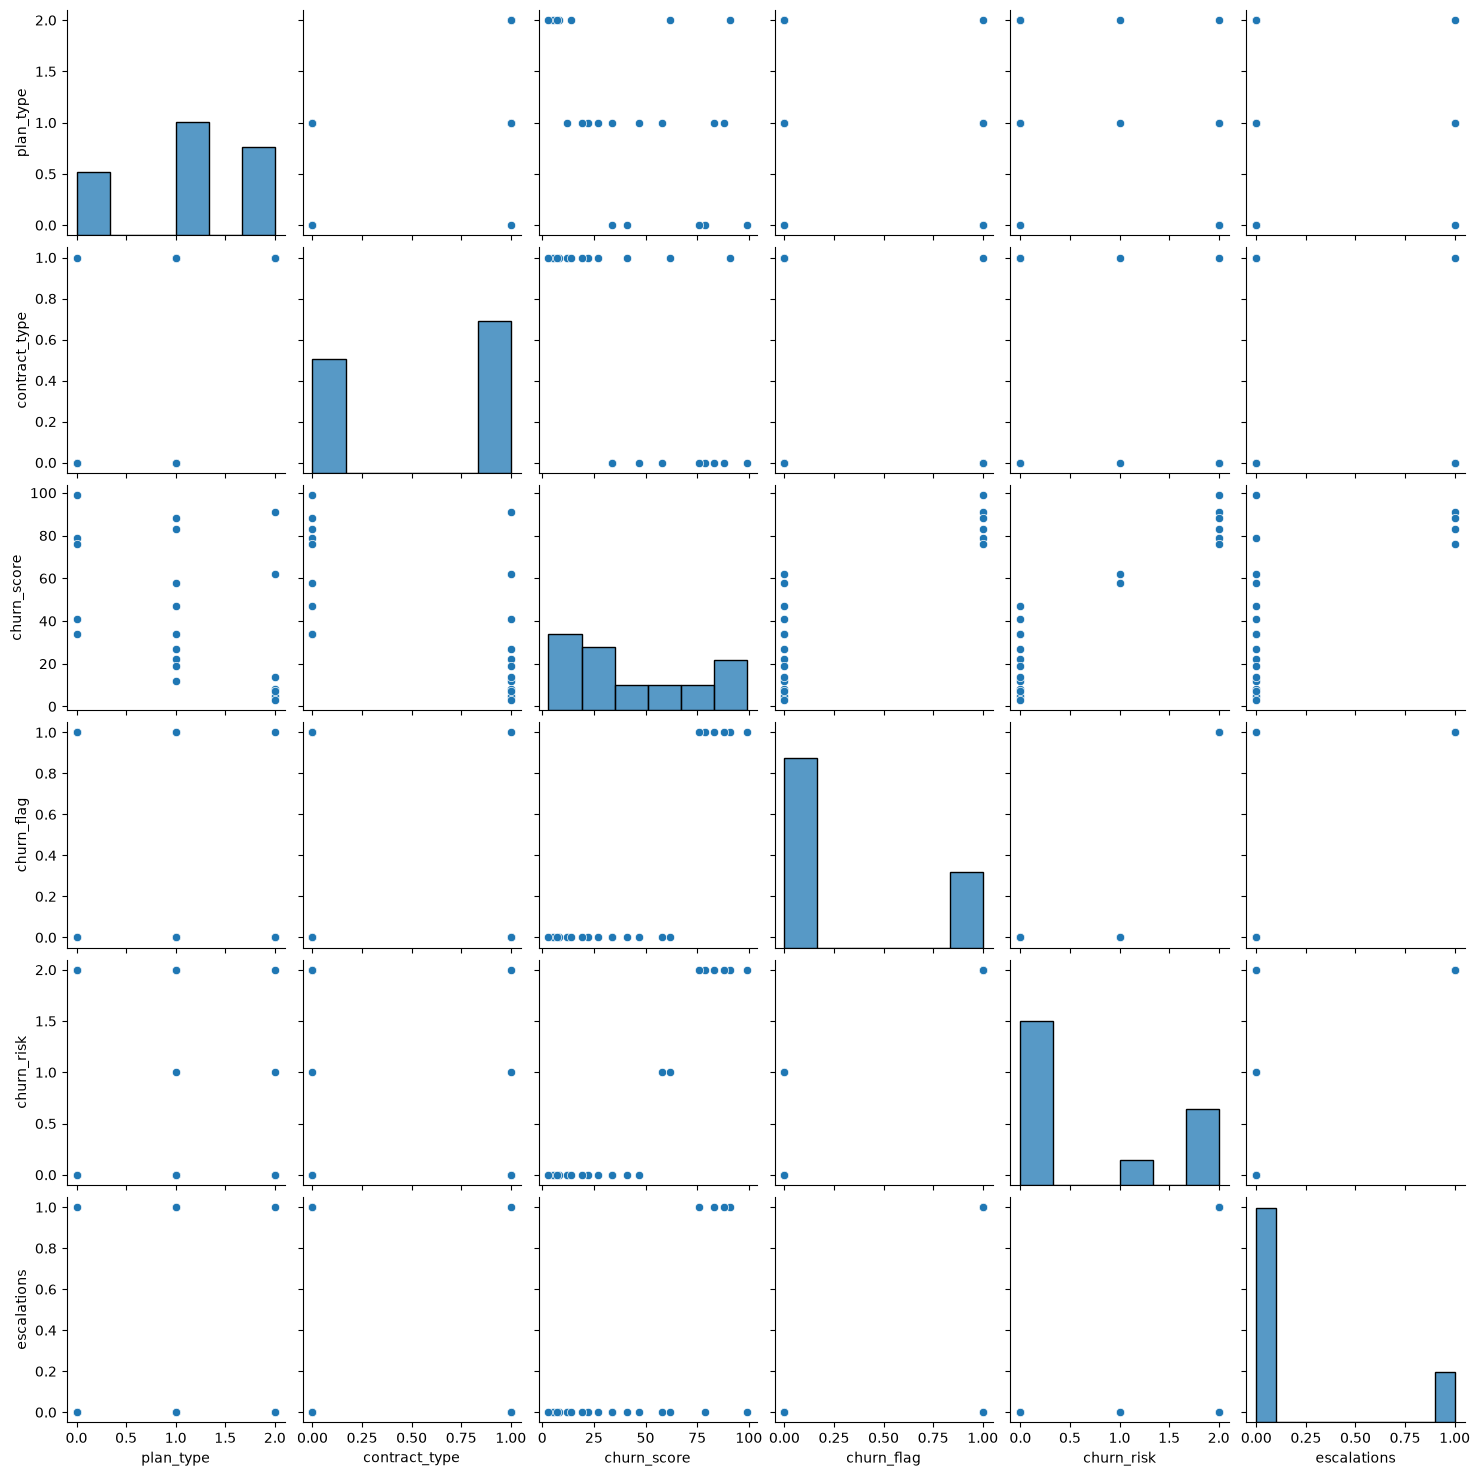

In [164]:
# pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [165]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

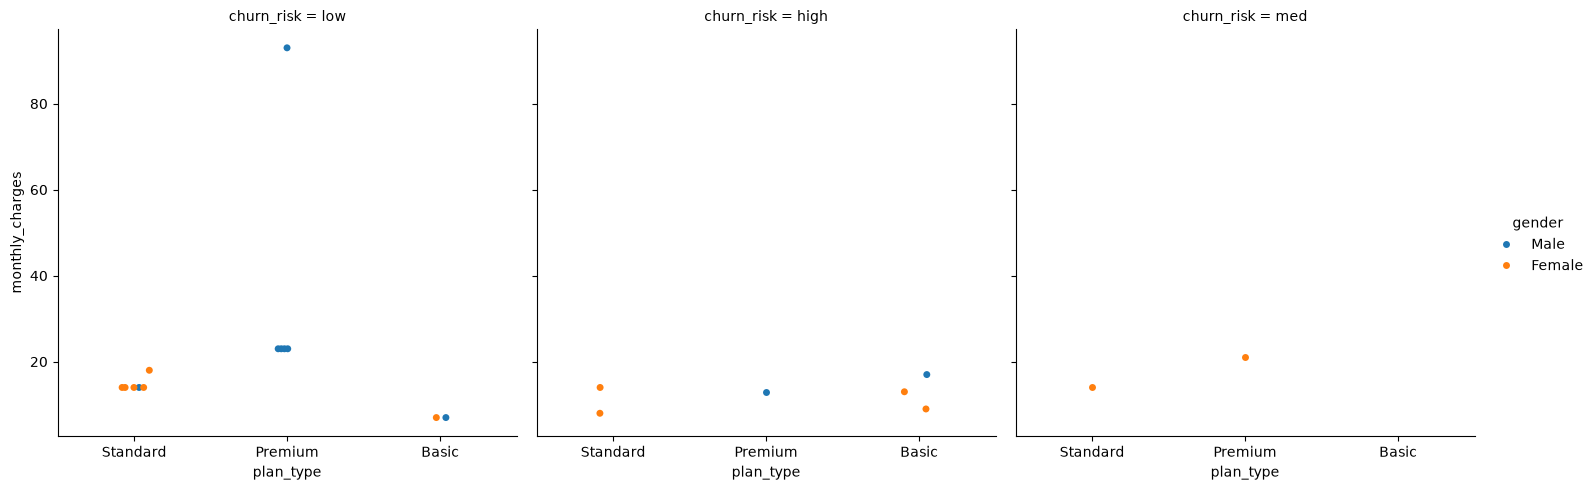

In [166]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk',)

In [ ]:
# Pivot Table

In [169]:
pd.pivot_table(
    df_visual,
    values='churn_flag',
    index='plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [170]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [171]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
# Working with SQL in Python (pandas)

In [185]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

conn.execute("DROP TABLE IF EXISTS users")

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

In [186]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2500),
            ('Vishakha', 'India', 3500)
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [187]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [192]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [193]:
# always close the conn with db once the task is over 
conn.close()

# 10. Key Business Insights and Risk Drivers

1. **Service Escalation Impact:** Unresolved customer service complaints and ticket escalations represent the single largest operational predictor of churn ($r = 0.77$).
2. **Plan Tier Vulnerability:** Basic plan subscribers exhibit an alarming **60.00% churn rate**, indicating potential gaps in feature value relative to competitor offerings or pricing friction.
3. **Acquisition Quality Discrepancy:** Referral channels suffer from a critical **83.33% attrition rate**, suggesting low lead qualification quality or unaligned customer expectations during onboarding.
4. **Revenue Leakage Exposure:** The business currently faces **$73.94k in monthly revenue at risk** directly attributable to customer cancellations.
5. **Contract Lifecycle Protection:** Long-term annual contracts act as a strong retention buffer, significantly reducing cancellation probability compared to month-to-month subscriptions ($r = -0.52$).

# 11. Strategic Business Recommendations and Future Scope

## 11.1 Actionable Business Recommendations
* **Proactive Support Resolution:** Implement an automated early-warning system for accounts with `escalations == 'Y'` to offer immediate intervention and dedicated agent assistance.
* **Basic Plan Restructuring:** Re-evaluate the feature set and onboarding experience of the Basic Plan to improve early retention.
* **Referral Program Audit:** Revise incentive structures and onboarding flows for referral sign-ups to ensure better product-market fit.
* **Contract Incentivization:** Provide targeted discounts for customers transitioning from monthly contracts to long-term annual plans.

## 11.2 Future Scope
* **Predictive Machine Learning:** Train supervised classification models (e.g., Logistic Regression, Random Forest, XGBoost) to predict individual customer churn probabilities before cancellation occurs.
* **Interactive Dashboarding:** Convert the static analytical pipeline into a dynamic Power BI / Tableau dashboard for real-time executive reporting.

# 12. Conclusion

This project successfully established an end-to-end data analytics pipeline to diagnose, quantify, and mitigate customer churn. By systematically processing customer demographics, subscription models, financial metrics, and support ticket interaction logs, the study identified the primary operational and behavioral drivers behind customer attrition.

## 12.1 Key Analytical Takeaways
* **Primary Churn Drivers:** Support ticket escalations and unoptimized acquisition channels—specifically referrals (83.33% churn)—represent the highest operational risk factors.
* **Financial Vulnerability:** The business faces an immediate revenue exposure of USD 73.94k per month, primarily stemming from high-friction tiers like the Basic Plan (60.00% churn rate).
* **Retention Levers:** Contract duration acts as the strongest stabilization mechanism, confirming that incentivizing long-term subscription models significantly protects customer lifetime value.

## 12.2 Final Executive Summary
By transitioning from a reactive retention model to a proactive, data-driven approach—focusing on priority support intervention for escalated accounts, restructuring lower-tier onboarding experiences, and incentivizing annual contracts—the business can effectively plug revenue leakage, enhance user satisfaction, and build a sustainable framework for long-term customer retention.